In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [16]:
image = cv2.imread('sar_2_color.jpg')

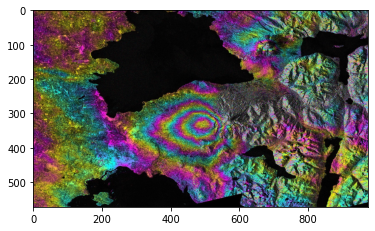

In [17]:
plt.imshow(image)

In [18]:
image.shape # h,w,c

(572, 974, 3)

In [19]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [20]:
# ROI
img_roi = image[100:200, 500:700]

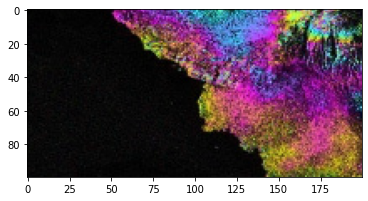

In [21]:
plt.imshow(img_roi)

In [22]:
b,g,r = cv2.split(image)

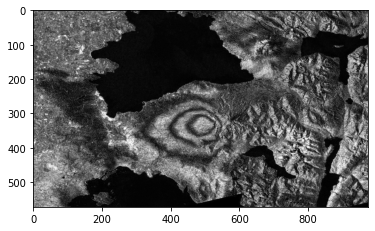

In [23]:
plt.imshow(b, cmap = 'gray')

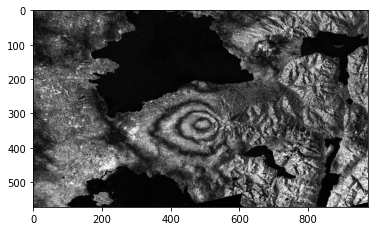

In [24]:
plt.imshow(g, cmap = 'gray')

In [25]:
# alternative approach
b = image[:,:,0]

In [26]:
import copy

image2 = copy.deepcopy(image)

In [27]:
image2[50:100,50:100] = [0,0,0]

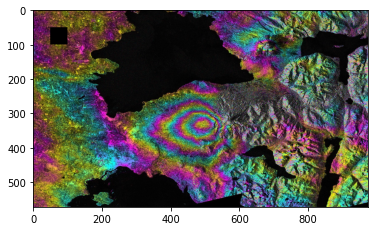

In [28]:
plt.imshow(image2)

In [29]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

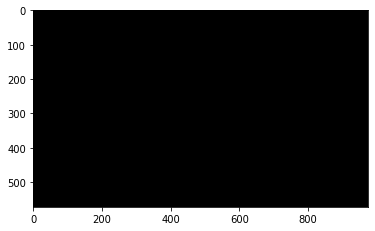

In [30]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [31]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [32]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [33]:
image_gray[0,0]

40

In [34]:
image_gray.shape

(572, 974)

In [35]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [36]:
image_hsv.shape

(572, 974, 3)

In [37]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [38]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [39]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [40]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [67]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

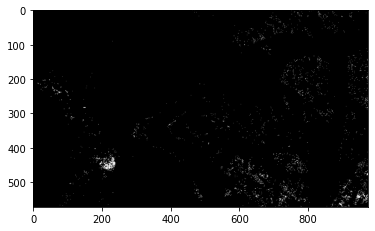

In [68]:
plt.imshow(thresh1, cmap='gray')

In [43]:
thresh1[thresh1==100].sum()

0

# Построение гистограммы

In [44]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

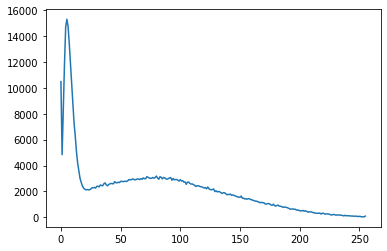

In [45]:
plt.plot(b_hist)

In [46]:
b_hist_cum = b_hist.cumsum()

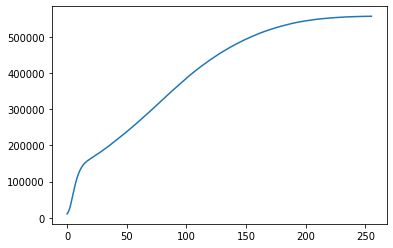

In [47]:
plt.plot(b_hist_cum)

In [49]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

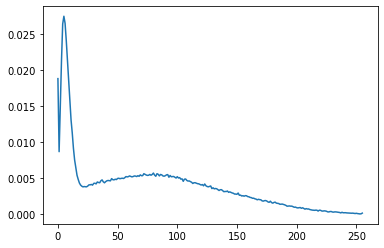

In [50]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [53]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


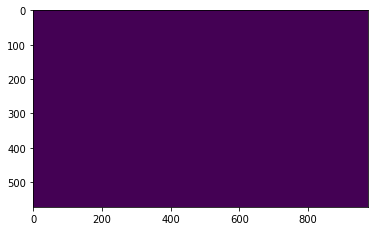

In [54]:
plt.imshow(diff)

In [55]:
mse = mean_squared_error(image_gray, image_gray)
mse

0.0

# Статистические характеристики изображений

In [56]:
mean = image_gray.mean()

In [57]:
std = image_gray.std()

In [58]:
print(mean,std)

67.41225535245043 52.016191875959635


In [60]:
eq_gray = cv2.equalizeHist(image_gray)

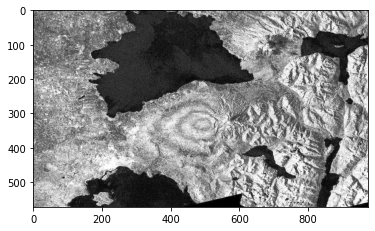

In [63]:
plt.imshow(eq_gray, cmap="gray")


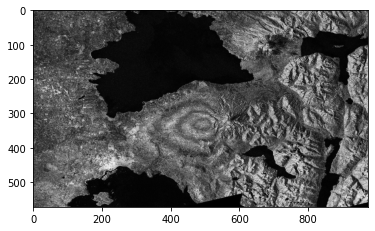

In [64]:
plt.imshow(image_gray, cmap="gray")

1. Изображение загружено
   shape = (400, 600), dtype = uint8
   min = 0, max = 255, mean = 74.94, std = 43.66


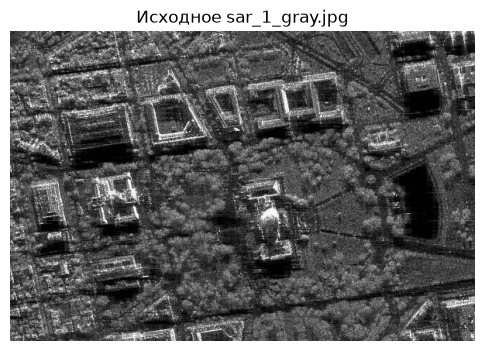


2. Гистограмма
   Сумма бинов = 240000 (должна быть равна числу пикселей: 240000)
   Бин с максимумом: 1, значение = 3786


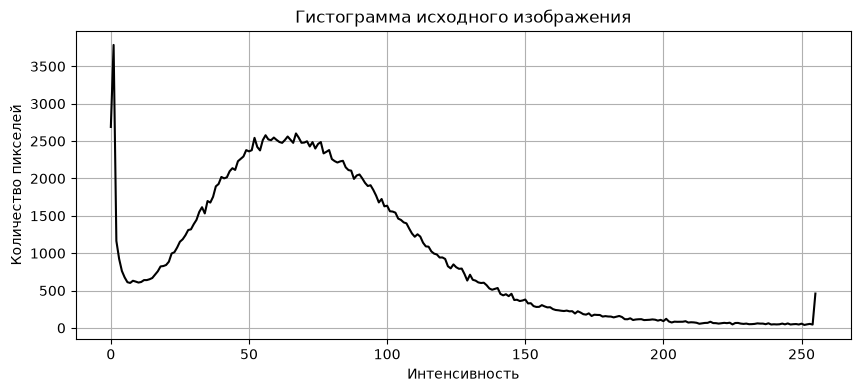


3. Гамма-коррекция
   gamma = 0.5: mean = 130.56, std = 43.86
   gamma = 1.0: mean = 74.94, std = 43.66
   gamma = 1.5: mean = 45.25, std = 39.25
   gamma = 2.2: mean = 24.64, std = 33.23


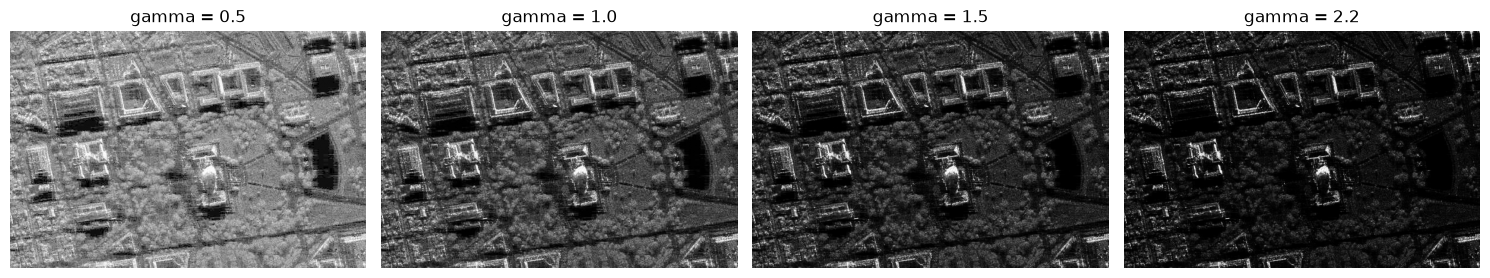


4. Сравнение исходного изображения и гамма-коррекции
   gamma |          MSE |         SSIM
--------------------------------------
     0.5 |    3250.4291 |     0.787501
     1.0 |       0.0000 |     1.000000
     1.5 |     971.8207 |     0.806579
     2.2 |    2894.0780 |     0.435637

5. Линейное растяжение гистограммы
   Исходное:      min = 0, max = 255, mean = 74.94, std = 43.66
   min-max:       min = 0, max = 255, mean = 74.94, std = 43.66
   1%-99%:        min = 0, max = 255, mean = 86.54, std = 49.96
   2%-98%:        min = 0, max = 255, mean = 97.97, std = 55.90

   Сравнение с исходным:
          метод |          MSE |         SSIM
   ------------------------------------------
        min-max |       0.0000 |     1.000000
         1%-99% |     180.0973 |     0.979395
         2%-98% |     710.1085 |     0.927940


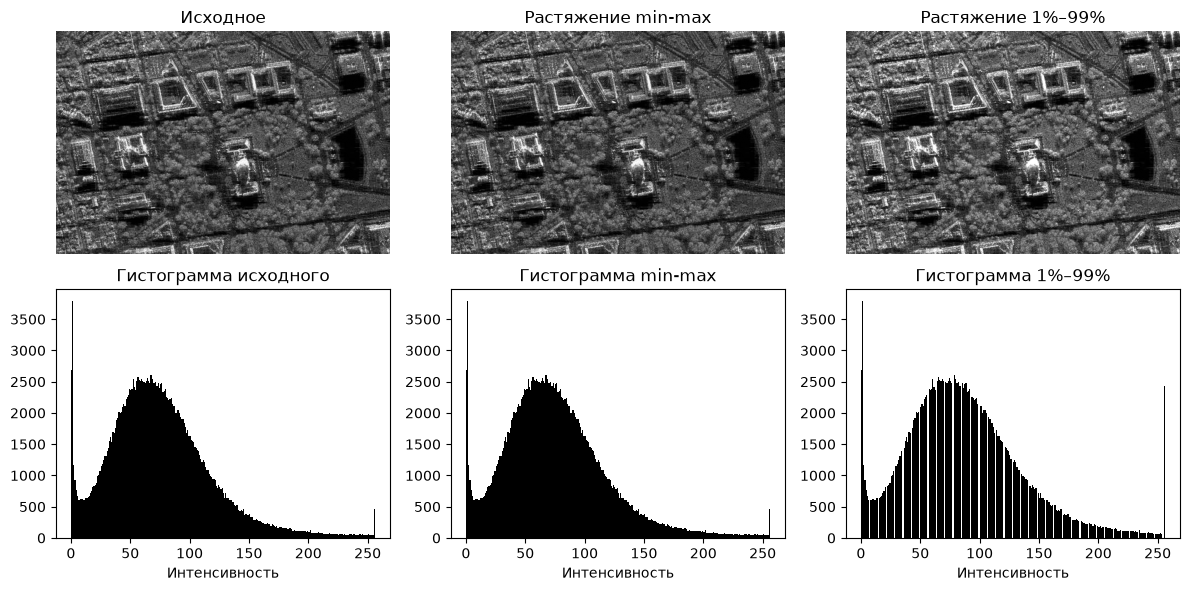


6. Пороговая фильтрация

   Тип: THRESH_BINARY
    threshold |   foreground_px | foreground_%
   ---------------------------------------------
           50 |          169178 |       70.49%
          100 |           55653 |       23.19%
          150 |           13083 |        5.45%
          200 |            3830 |        1.60%

   Тип: THRESH_BINARY_INV
    threshold |   foreground_px | foreground_%
   ---------------------------------------------
           50 |           70822 |       29.51%
          100 |          184347 |       76.81%
          150 |          226917 |       94.55%
          200 |          236170 |       98.40%

   Тип: THRESH_TRUNC
    threshold |   foreground_px | foreground_%
   ---------------------------------------------
           50 |          237311 |       98.88%
          100 |          237311 |       98.88%
          150 |          237311 |       98.88%
          200 |          237311 |       98.88%

   Тип: THRESH_TOZERO
    threshold |   foreground

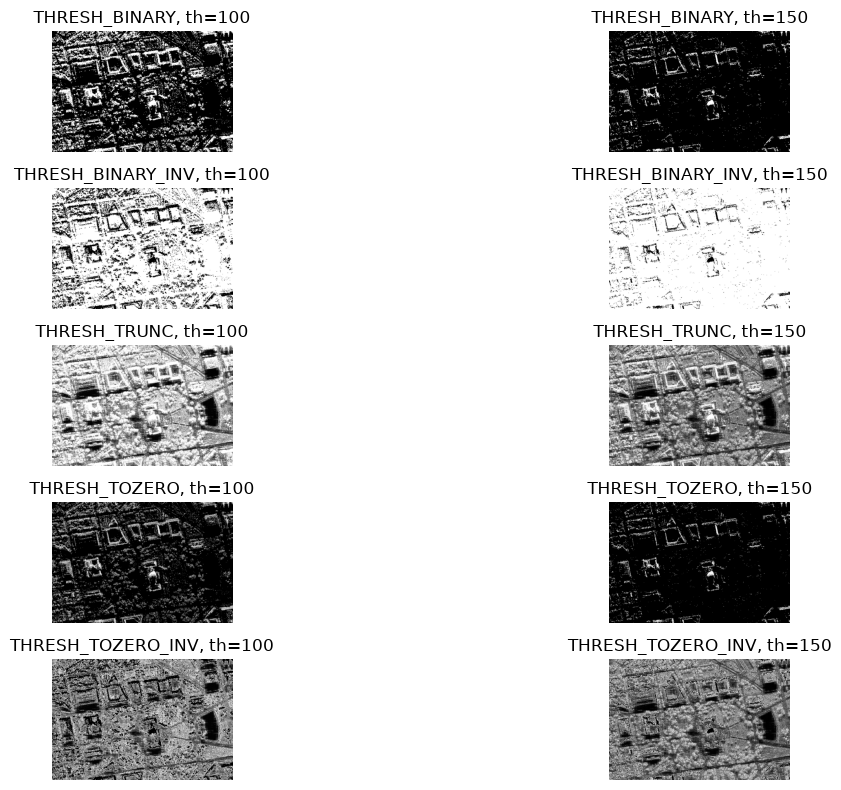

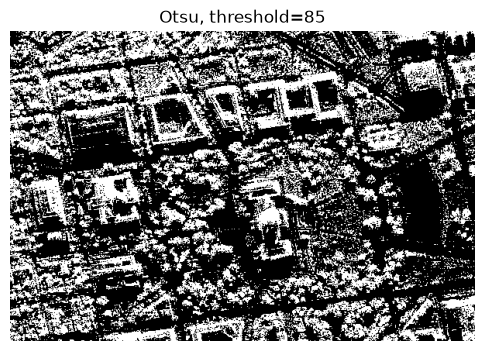

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Не найден файл sar_1_gray.jpg")

print("1. Изображение загружено")
print(f"   shape = {img.shape}, dtype = {img.dtype}")
print(f"   min = {img.min()}, max = {img.max()}, mean = {img.mean():.2f}, std = {img.std():.2f}")

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title('Исходное sar_1_gray.jpg')
plt.axis('off')
plt.show()


hist = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()

print("\n2. Гистограмма")
print(f"   Сумма бинов = {hist.sum():.0f} (должна быть равна числу пикселей: {img.size})")
print(f"   Бин с максимумом: {hist.argmax()}, значение = {hist.max():.0f}")

plt.figure(figsize=(10, 4))
plt.plot(hist, color='black')
plt.title('Гистограмма исходного изображения')
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.grid(True)
plt.show()


def gamma_correction(image, gamma):
    """
    Гамма-коррекция.
    gamma < 1 — осветление,
    gamma > 1 — затемнение,
    gamma = 1 — без изменений.
    """
    img_float = image.astype(np.float32) / 255.0
    corrected = np.power(img_float, gamma) * 255.0
    return np.clip(corrected, 0, 255).astype(np.uint8)

gammas = [0.5, 1.0, 1.5, 2.2]
gamma_images = {}

print("\n3. Гамма-коррекция")
for g in gammas:
    corrected = gamma_correction(img, g)
    gamma_images[g] = corrected
    print(f"   gamma = {g}: mean = {corrected.mean():.2f}, std = {corrected.std():.2f}")

plt.figure(figsize=(15, 4))
for i, g in enumerate(gammas, 1):
    plt.subplot(1, len(gammas), i)
    plt.imshow(gamma_images[g], cmap='gray')
    plt.title(f'gamma = {g}')
    plt.axis('off')
plt.tight_layout()
plt.show()


print("\n4. Сравнение исходного изображения и гамма-коррекции")
print(f"{'gamma':>8} | {'MSE':>12} | {'SSIM':>12}")
print("-" * 38)

for g in gammas:
    corrected = gamma_images[g]
    mse_value = mse(img, corrected)
    ssim_value = ssim(img, corrected, data_range=255)
    print(f"{g:>8} | {mse_value:>12.4f} | {ssim_value:>12.6f}")


print("\n5. Линейное растяжение гистограммы")

def linear_stretch(image, low_percentile=0, high_percentile=100):
    """
    Линейное растяжение гистограммы.
    low_percentile / high_percentile — отсекаемые проценты (0..100).
    При 0 и 100 используется абсолютный min/max.
    """
    img_float = image.astype(np.float32)

    low = np.percentile(img_float, low_percentile)
    high = np.percentile(img_float, high_percentile)

    if high <= low:
        return image.copy()

    stretched = (img_float - low) * (255.0 / (high - low))
    return np.clip(stretched, 0, 255).astype(np.uint8)


stretched_minmax = linear_stretch(img, 0, 100)


stretched_p1 = linear_stretch(img, 1, 99)


stretched_p2 = linear_stretch(img, 2, 98)

print(f"   Исходное:      min = {img.min()}, max = {img.max()}, "
      f"mean = {img.mean():.2f}, std = {img.std():.2f}")
print(f"   min-max:       min = {stretched_minmax.min()}, max = {stretched_minmax.max()}, "
      f"mean = {stretched_minmax.mean():.2f}, std = {stretched_minmax.std():.2f}")
print(f"   1%-99%:        min = {stretched_p1.min()}, max = {stretched_p1.max()}, "
      f"mean = {stretched_p1.mean():.2f}, std = {stretched_p1.std():.2f}")
print(f"   2%-98%:        min = {stretched_p2.min()}, max = {stretched_p2.max()}, "
      f"mean = {stretched_p2.mean():.2f}, std = {stretched_p2.std():.2f}")

# Сравнение MSE и SSIM
print("\n   Сравнение с исходным:")
print(f"   {'метод':>12} | {'MSE':>12} | {'SSIM':>12}")
print("   " + "-" * 42)
for name, im in [('min-max', stretched_minmax),
                 ('1%-99%', stretched_p1),
                 ('2%-98%', stretched_p2)]:
    mse_val = mse(img, im)
    ssim_val = ssim(img, im, data_range=255)
    print(f"   {name:>12} | {mse_val:>12.4f} | {ssim_val:>12.6f}")

# Гистограммы до и после
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(stretched_minmax, cmap='gray')
plt.title('Растяжение min-max')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(stretched_p1, cmap='gray')
plt.title('Растяжение 1%–99%')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(img.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Гистограмма исходного')
plt.xlabel('Интенсивность')

plt.subplot(2, 3, 5)
plt.hist(stretched_minmax.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Гистограмма min-max')
plt.xlabel('Интенсивность')

plt.subplot(2, 3, 6)
plt.hist(stretched_p1.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Гистограмма 1%–99%')
plt.xlabel('Интенсивность')

plt.tight_layout()
plt.show()

print("\n6. Пороговая фильтрация")

thresholds = [50, 100, 150, 200]
types = {
    'THRESH_BINARY': cv2.THRESH_BINARY,
    'THRESH_BINARY_INV': cv2.THRESH_BINARY_INV,
    'THRESH_TRUNC': cv2.THRESH_TRUNC,
    'THRESH_TOZERO': cv2.THRESH_TOZERO,
    'THRESH_TOZERO_INV': cv2.THRESH_TOZERO_INV,
}

for name, ttype in types.items():
    print(f"\n   Тип: {name}")
    print(f"   {'threshold':>10} | {'foreground_px':>15} | {'foreground_%':>12}")
    print("   " + "-" * 45)

    for th in thresholds:
        _, th_img = cv2.threshold(img, th, 255, ttype)

        if ttype in (cv2.THRESH_BINARY, cv2.THRESH_BINARY_INV):
            foreground = np.count_nonzero(th_img == 255)
        else:
            foreground = np.count_nonzero(th_img)

        percent = 100.0 * foreground / img.size
        print(f"   {th:>10} | {foreground:>15} | {percent:>11.2f}%")

otsu_th, otsu_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"\n   Otsu threshold = {otsu_th:.0f}")
print(f"   foreground_px = {np.count_nonzero(otsu_img == 255)}")

plt.figure(figsize=(15, 8))
plot_idx = 1
for name, ttype in types.items():
    for th in [100, 150]:
        _, th_img = cv2.threshold(img, th, 255, ttype)
        plt.subplot(len(types), 2, plot_idx)
        plt.imshow(th_img, cmap='gray')
        plt.title(f'{name}, th={th}')
        plt.axis('off')
        plot_idx += 1
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(otsu_img, cmap='gray')
plt.title(f'Otsu, threshold={otsu_th:.0f}')
plt.axis('off')
plt.show()

